# a4 - Segmentation: who is retained
learn-customer-retention-with-phoebe - by Phoebe Fu

Averages lie. This notebook scores every customer on Recency, Frequency, Monetary value (RFM),
names the personas, catches the wholesalers eating the averages, and compares two behavioral
cohorts (fast second purchase vs slow) on their retention curves.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "run this notebook from the repo root or notebooks/"
np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

orders = pd.read_csv(ROOT / "data" / "ecommerce_orders.csv", parse_dates=["order_date"])
snapshot = orders["order_date"].max() + pd.Timedelta(days=1)
print(f"snapshot date: {snapshot.date()}")

rfm = orders.groupby("customer_id").agg(
    recency=("order_date", lambda s: (snapshot - s.max()).days),
    frequency=("order_date", "count"),
    monetary=("order_value", "sum"),
    segment=("segment", "first"))
rfm.head()

snapshot date: 2026-07-29


,recency,frequency,monetary,segment
customer_id,,,,
C00000,22,11,413.030,retail
C00001,39,3,95.250,retail
C00002,224,2,75.060,retail
C00003,351,3,99.830,retail
C00004,72,3,94.040,retail


## Quintile scores

Each dimension becomes a 1-5 score via qcut on the RANK (rank first so ties do not break the
quantile cut). Recency is reversed: the most recent buyers get 5. Code 555 is the best customer
in the book.

In [2]:
rfm["R"] = pd.qcut(rfm["recency"].rank(method="first"), 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["code"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

def persona(row):
    if row["code"] in ("555", "554"):
        return "Champions"
    if row["R"] >= 4 and row["F"] >= 4:
        return "Loyal"
    if row["R"] <= 2 and row["F"] >= 4:
        return "At-Risk"
    if row["R"] <= 2 and row["F"] <= 2:
        return "Hibernating"
    return "Everyone else"

rfm["persona"] = rfm.apply(persona, axis=1)
summary = rfm.groupby("persona").agg(customers=("code", "size"), revenue=("monetary", "sum"))
summary["customer_share"] = summary["customers"] / summary["customers"].sum()
summary["revenue_share"] = summary["revenue"] / summary["revenue"].sum()
summary.sort_values("revenue_share", ascending=False).round(3)

,customers,revenue,customer_share,revenue_share
persona,,,,
Champions,434,"544,962.650",0.108,0.526
Everyone else,1669,"195,977.690",0.414,0.189
Loyal,669,"188,064.440",0.166,0.182
At-Risk,257,"59,718.140",0.064,0.058
Hibernating,1001,"46,659.860",0.248,0.045


Champions: 434 customers, of which 30 are wholesalers (7%)
Lesson: a persona built on raw R/F/M lets 30 wholesale accounts colonize the top box.
Score B2B and B2C books separately, or the 'best customers' list is just your resellers.


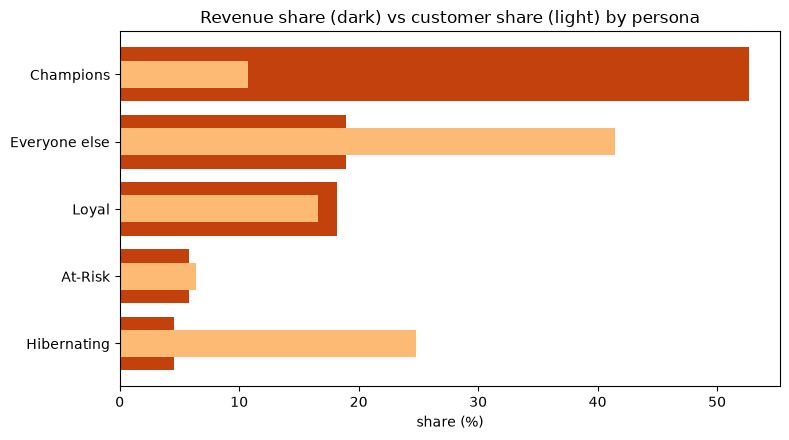

In [3]:
champs = rfm[rfm["persona"] == "Champions"]
n_wholesale = champs.index.str.startswith("W").sum()
print(f"Champions: {len(champs)} customers, of which {n_wholesale} are wholesalers "
      f"({n_wholesale / len(champs):.0%})")
print("Lesson: a persona built on raw R/F/M lets 30 wholesale accounts colonize the top box.")
print("Score B2B and B2C books separately, or the 'best customers' list is just your resellers.")

fig, ax = plt.subplots(figsize=(8, 4.5))
order = summary.sort_values("revenue_share", ascending=True)
ax.barh(order.index, order["revenue_share"] * 100, color="#C2410C")
ax.barh(order.index, order["customer_share"] * 100, color="#FDBA74", height=0.4)
ax.set_xlabel("share (%)")
ax.set_title("Revenue share (dark) vs customer share (light) by persona")
plt.tight_layout()
plt.show()

## Behavioral cohort: the fast second purchase

Acquisition cohorts group people by WHEN they arrived; behavioral cohorts group them by WHAT they
did. Industry folklore says most second orders land within 90 days; here we split customers on
whether the second purchase arrived within 30 days of the first, and overlay the two monthly
retention curves. (Single-order customers fall in the "no" group by construction, which is part
of why the gap is so large - a teaching point, not a bug.)

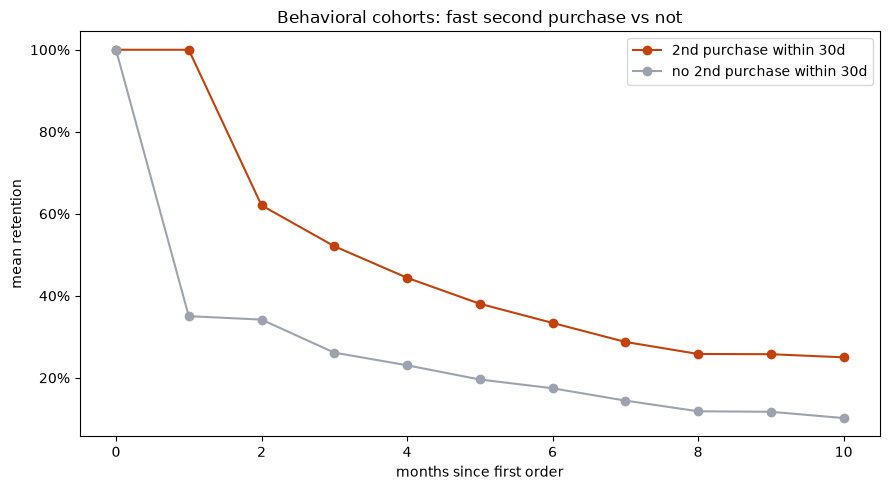

1,277 retail customers made a second purchase within 30 days


In [4]:
retail = orders[orders["segment"] == "retail"].copy()
firsts = retail.groupby("customer_id")["order_date"].min().rename("first_order")
retail = retail.join(firsts, on="customer_id")
second = (retail[retail["order_date"] > retail["first_order"]]
          .groupby("customer_id")["order_date"].min())
gap = (second - firsts.loc[second.index]).dt.days
fast_ids = set(gap[gap <= 30].index)
retail["group"] = np.where(retail["customer_id"].isin(fast_ids),
                           "2nd purchase within 30d", "no 2nd purchase within 30d")

retail["order_month"] = retail["order_date"].dt.to_period("M")
retail["cohort"] = retail["first_order"].dt.to_period("M")
retail["period_number"] = (retail["order_month"] - retail["cohort"]).apply(lambda p: p.n)

fig, ax = plt.subplots(figsize=(9, 5))
for grp, color in [("2nd purchase within 30d", "#C2410C"),
                   ("no 2nd purchase within 30d", "#9CA3AF")]:
    sub = retail[retail["group"] == grp]
    c = sub.pivot_table(index="cohort", columns="period_number",
                        values="customer_id", aggfunc="nunique")
    curve = c.divide(c.iloc[:, 0], axis=0).mean(axis=0)
    curve = curve[curve.index <= 10]
    ax.plot(curve.index, curve.values, marker="o", color=color, label=grp)
ax.set_xlabel("months since first order")
ax.set_ylabel("mean retention")
ax.set_title("Behavioral cohorts: fast second purchase vs not")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend()
plt.tight_layout()
plt.show()
print(f"{len(fast_ids):,} retail customers made a second purchase within 30 days")

## The power-user curve again (L28)

Segmentation's other face: the distribution of engagement intensity. Active days per player in
the first 28 days on the game data.

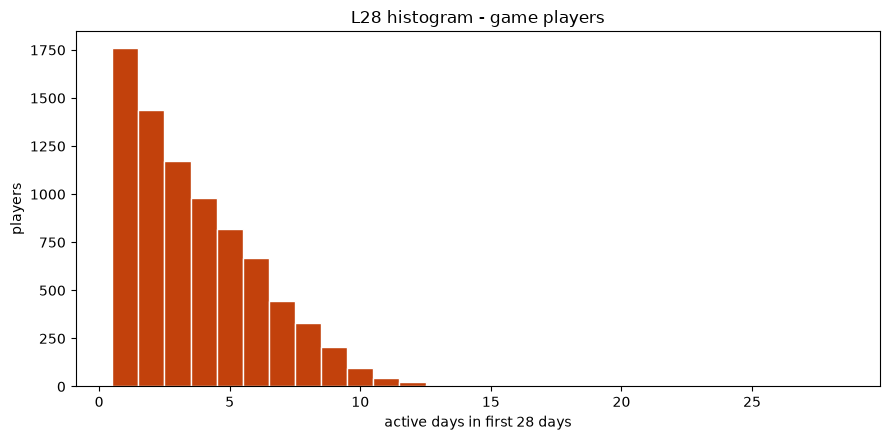

22% of players were active exactly 1 day; 0.0% were active 15+ days.


In [5]:
game = pd.read_csv(ROOT / "data" / "game_telemetry.csv",
                   parse_dates=["install_date", "activity_date"])
game["day"] = (game["activity_date"] - game["install_date"]).dt.days
active_days = game[game["day"] <= 27].groupby("user_id")["day"].nunique()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(active_days, bins=np.arange(0.5, 29.5, 1), color="#C2410C", edgecolor="white")
ax.set_xlabel("active days in first 28 days")
ax.set_ylabel("players")
ax.set_title("L28 histogram - game players")
plt.tight_layout()
plt.show()
share_1day = (active_days == 1).mean()
share_15plus = (active_days >= 15).mean()
print(f"{share_1day:.0%} of players were active exactly 1 day; {share_15plus:.1%} were active 15+ days.")

**Shape comment**: this is a left-slumped curve, not a smile. The overwhelming mass sits at
one active day (install day only) and the frequency decays monotonically; there is no second bump
of hardcore daily players on the right. That is the signature of a game that has not yet built a
habit-forming core loop - a DAU/MAU ratio alone would have hidden this entirely.